In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cycler

In [3]:
df_test_1 = pd.read_csv("trained_backbones/backbone_test1/results/evaluation_results.csv")
df_test_2 = pd.read_csv("trained_backbones/backbone_test4/results/evaluation_results.csv")
df_train_1 = pd.read_csv("logs/classification_head_1775690763_contrastive/training.csv")
df_train_2 = pd.read_csv("logs/classification_head_1775691142_contrastive/training.csv")
df_imagenet = pd.read_csv("logs/classification_head_1775702561_imagenet/training.csv")

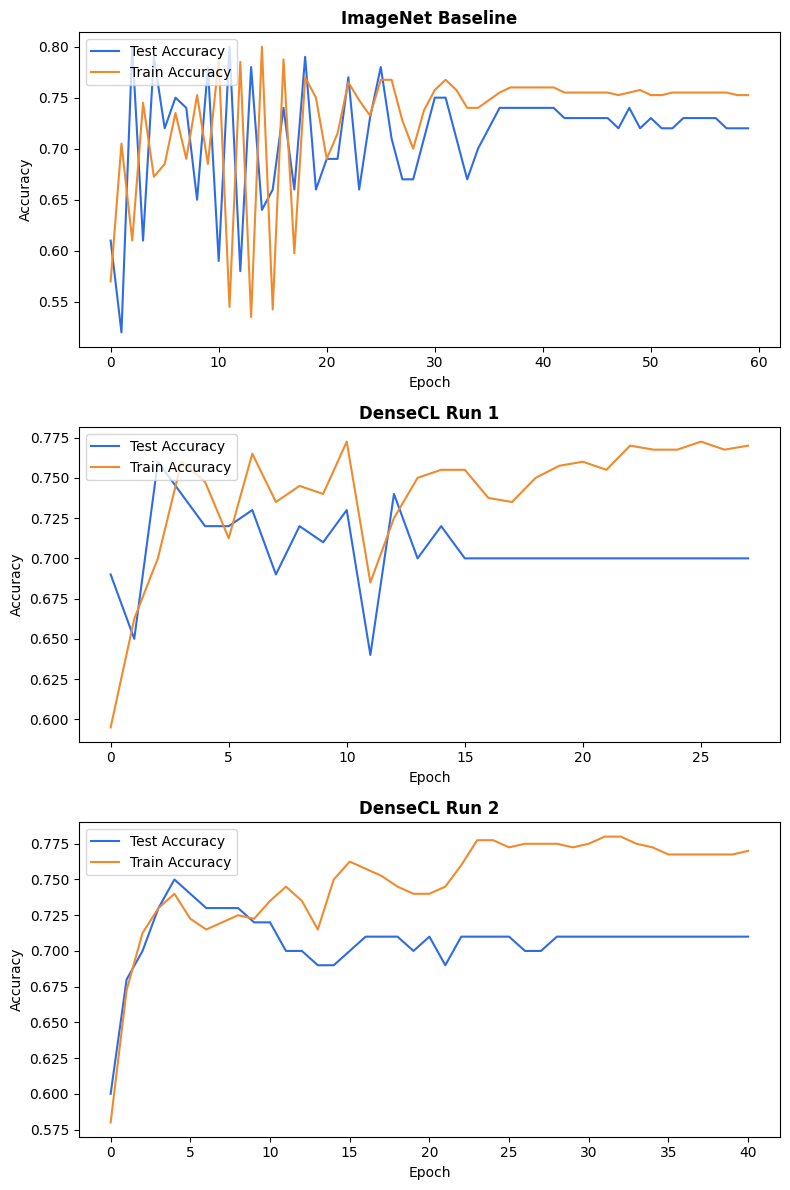

In [4]:
TEST_COLOR = "#2E6BE6"
TRAIN_COLOR = "#F08A2C"
TEXT_COLOR = "#000000"
fig, ax = plt.subplots(3, 1, figsize=(8, 12))
ax[1].set_title("DenseCL Run 1", fontweight="bold", color=TEXT_COLOR)
ax[2].set_title("DenseCL Run 2", fontweight="bold", color=TEXT_COLOR)
ax[0].set_title("ImageNet Baseline", fontweight="bold", color=TEXT_COLOR)

ax[1].plot(df_train_1["epoch"], df_train_1["val_accuracy"], label="Test Accuracy", color=TEST_COLOR)
ax[1].plot(df_train_1["epoch"], df_train_1["accuracy"], label="Train Accuracy", color=TRAIN_COLOR)
ax[1].legend(loc="upper left")
ax[2].plot(df_train_2["epoch"], df_train_2["val_accuracy"], label="Test Accuracy", color=TEST_COLOR)
ax[2].plot(df_train_2["epoch"], df_train_2["accuracy"], label="Train Accuracy", color=TRAIN_COLOR)
ax[2].legend(loc="upper left")
ax[0].plot(df_imagenet["epoch"], df_imagenet["val_accuracy"], label="Test Accuracy", color=TEST_COLOR)
ax[0].plot(df_imagenet["epoch"], df_imagenet["accuracy"], label="Train Accuracy", color=TRAIN_COLOR)
ax[0].legend(loc="upper left")
for a in ax:
    a.set_xlabel("Epoch")
    a.set_ylabel("Accuracy")

fig.tight_layout()
plt.savefig("figs/accuracy_curves.png")


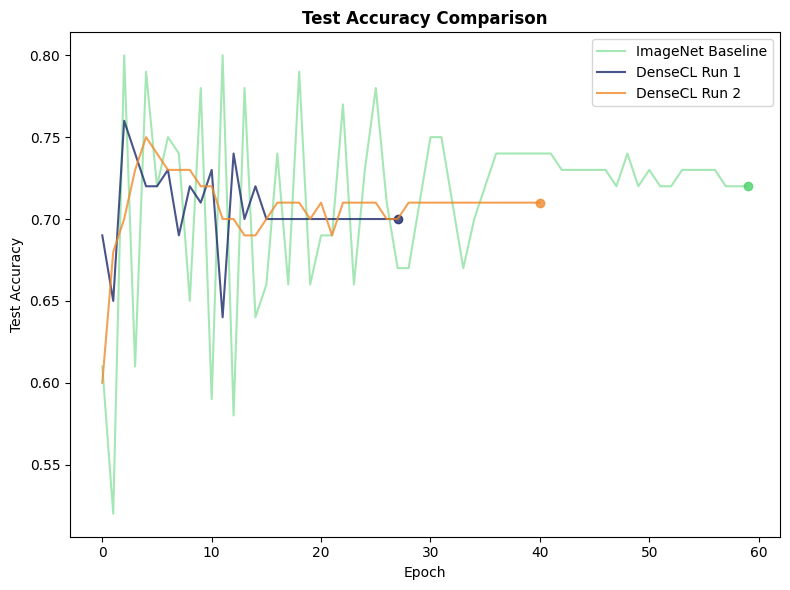

In [22]:
blue="#1B2A6B"
orange="#F08A2C"
green="#4BD16A"
plt.figure(figsize=(8, 6))
plt.plot(df_imagenet["epoch"], df_imagenet["val_accuracy"], label="ImageNet Baseline", alpha=0.5, color=green)
plt.plot(df_imagenet["epoch"].iloc[-1], df_imagenet["val_accuracy"].iloc[-1], marker="o", alpha=0.8, color=green)
plt.plot(df_train_1["epoch"], df_train_1["val_accuracy"], label="DenseCL Run 1", alpha=0.8, color=blue)
plt.plot(df_train_1["epoch"].iloc[-1], df_train_1["val_accuracy"].iloc[-1], marker="o", alpha=0.8, color=blue)
plt.plot(df_train_2["epoch"], df_train_2["val_accuracy"], label="DenseCL Run 2", alpha=0.8, color=orange)
plt.plot(df_train_2["epoch"].iloc[-1], df_train_2["val_accuracy"].iloc[-1], marker="o", alpha=0.8, color=orange)
plt.title("Test Accuracy Comparison", fontweight="bold", color=TEXT_COLOR)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("figs/test_accuracy_comparison.png")

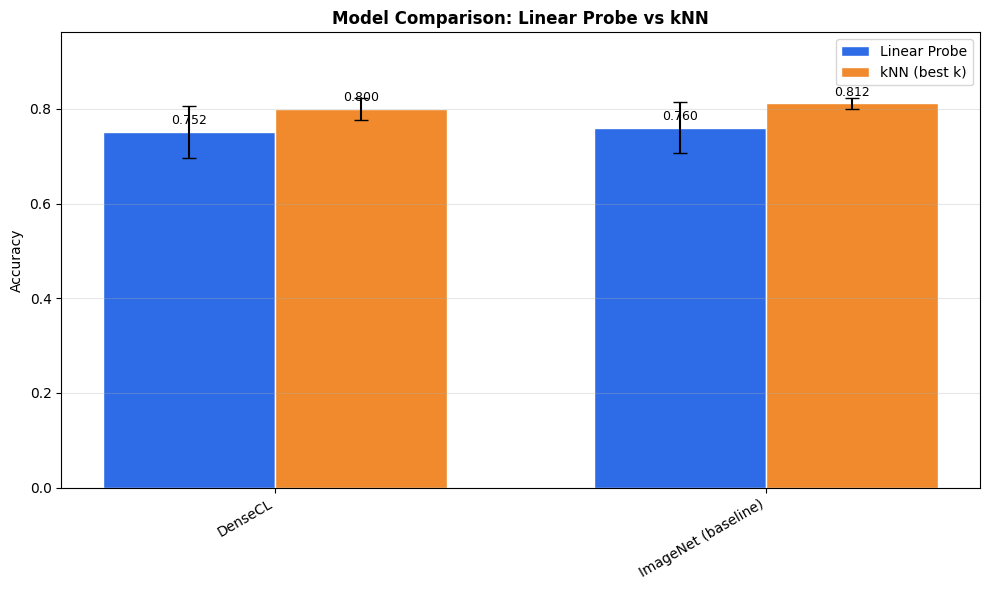

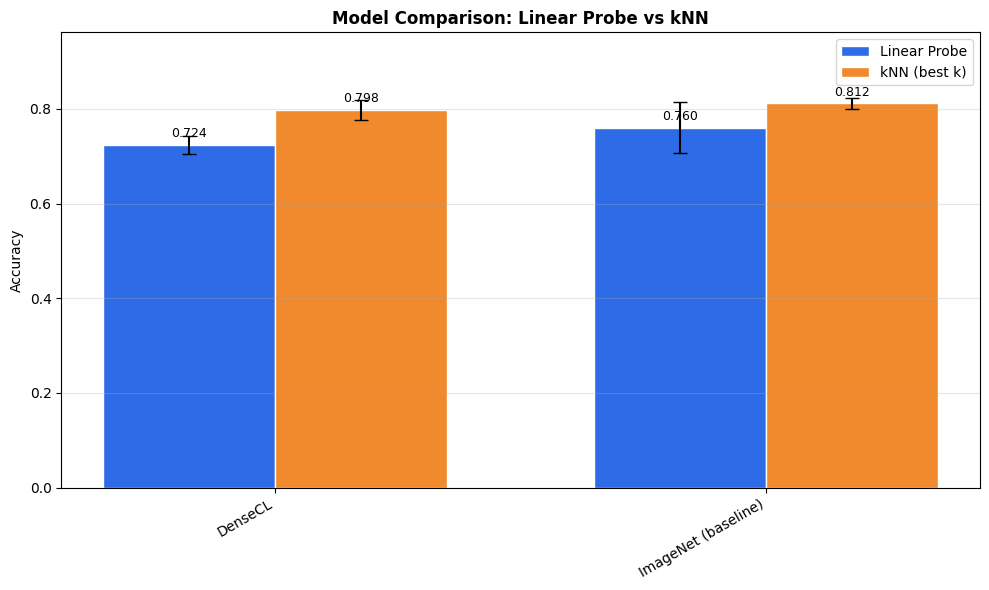

In [47]:
def plot_model_comparison(df, output_dir=".", name="model_comparison"):
    # Linear probe: one value per model
    lp = df.groupby("model")[["linear_probe_acc", "linear_probe_std"]].first()

    # kNN: pick best k per model
    idx = df.groupby("model")["knn_acc"].idxmax()
    knn = df.loc[idx].set_index("model")[["knn_acc", "knn_std", "knn_k"]]

    model_names = list(lp.index)
    n = len(model_names)
    lp_accs = lp["linear_probe_acc"].values
    lp_stds = lp["linear_probe_std"].values
    knn_accs = knn.loc[model_names, "knn_acc"].values
    knn_stds = knn.loc[model_names, "knn_std"].values

    x = np.arange(n)
    w = 0.35

    fig, ax = plt.subplots(figsize=(max(10, n * 2.5), 6))
    b1 = ax.bar(x - w/2, lp_accs, w, yerr=lp_stds, label="Linear Probe",
                capsize=5, color="#2E6BE6", edgecolor="white")
    b2 = ax.bar(x + w/2, knn_accs, w, yerr=knn_stds, label="kNN (best k)",
                capsize=5, color="#F08A2C", edgecolor="white")

    for b in list(b1) + list(b2):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Accuracy")
    ax.set_title("Model Comparison: Linear Probe vs kNN", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha="right")
    ax.legend()
    ax.set_ylim(0, min(1.0, max(lp_accs.max(), knn_accs.max()) + 0.15))
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_model_comparison(df_test_1, output_dir="figs", name="test1_comparison")
plot_model_comparison(df_test_2, output_dir="figs", name="test2_comparison")

In [2]:
contrastive_pbi_df = pd.read_csv("training/plain_contrastive_80_pbi_ResNet50_backbone_training_metrics.csv")
random_pbi_df = pd.read_csv("training/plain_random_pbi_ResNet50_backbone_training_metrics.csv")
imagenet_pbi_df = pd.read_csv("training/plain_imagenet_pbi_ResNet50_backbone_training_metrics.csv")
contrastive_streamer_df = pd.read_csv("training/plain_contrastive_80_streamer_ResNet50_backbone_training_metrics.csv")
random_streamer_df = pd.read_csv("training/plain_random_streamer_ResNet50_backbone_training_metrics.csv")
imagenet_streamer_df = pd.read_csv("training/plain_imagenet_streamer_ResNet50_backbone_training_metrics.csv")

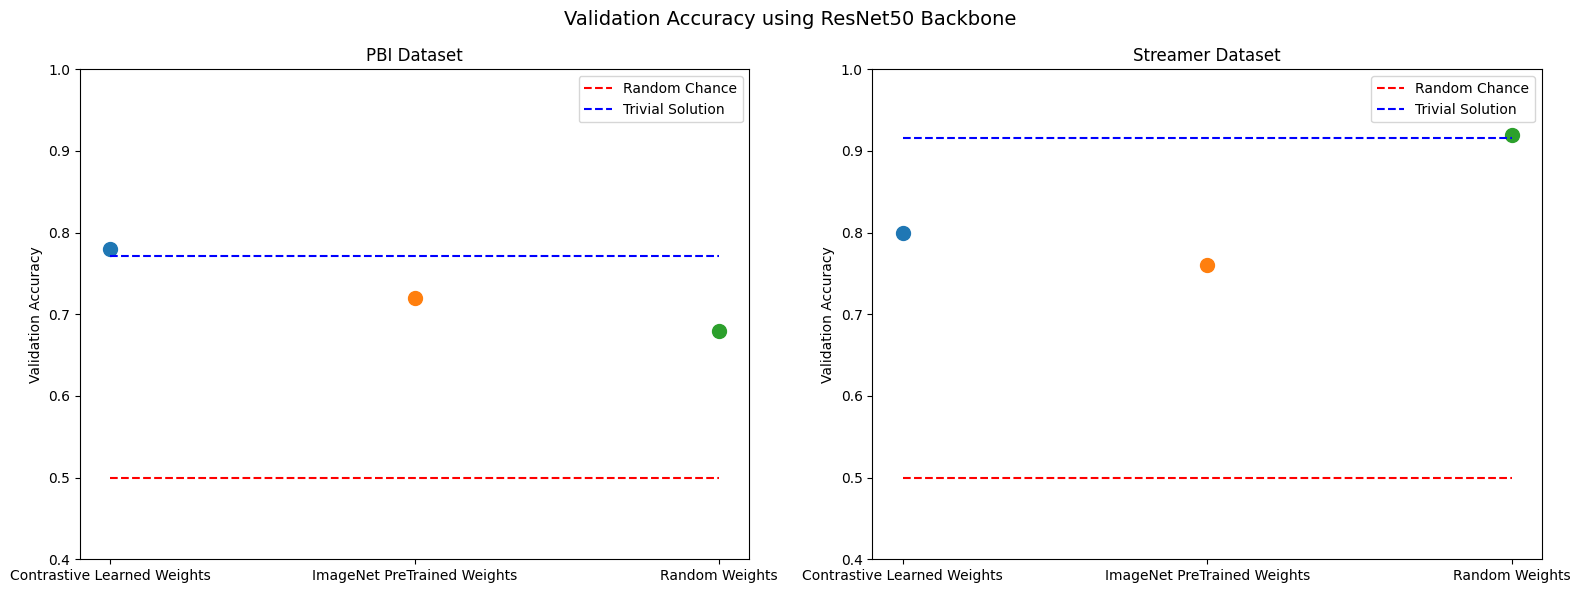

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PBI Dataset
val_auc_pbi = {
    "Contrastive Learned Weights": contrastive_pbi_df.iloc[-1]["val_accuracy"],
    "ImageNet PreTrained Weights": imagenet_pbi_df.iloc[-1]["val_accuracy"],
    "Random Weights": random_pbi_df.iloc[-1]["val_accuracy"],
}

for i, (key, value) in enumerate(val_auc_pbi.items()):
    ax1.scatter(i, value, s=100)
ax1.hlines(y=0.5, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax1.hlines(y=(1 - 0.228), xmin=0, xmax=2, colors="blue", linestyles="dashed", label="Trivial Solution")
ax1.set_ylim(0.4, 1)
ax1.set_xticks(range(len(val_auc_pbi)))
ax1.set_xticklabels(list(val_auc_pbi.keys()))
ax1.set_ylabel("Validation Accuracy")
ax1.legend()
ax1.set_title("PBI Dataset")

# Streamer Dataset
val_auc_streamer = {
    "Contrastive Learned Weights": contrastive_streamer_df.iloc[-1]["val_accuracy"],
    "ImageNet PreTrained Weights": imagenet_streamer_df.iloc[-1]["val_accuracy"],
    "Random Weights": random_streamer_df.iloc[-1]["val_accuracy"],
}

for i, (key, value) in enumerate(val_auc_streamer.items()):
    ax2.scatter(i, value, s=100)
ax2.hlines(y=0.5, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax2.hlines(y=(1 - 0.084), xmin=0, xmax=2, colors="blue", linestyles="dashed", label="Trivial Solution")
ax2.set_ylim(0.4, 1)
ax2.set_xticks(range(len(val_auc_streamer)))
ax2.set_xticklabels(list(val_auc_streamer.keys()))
ax2.set_ylabel("Validation Accuracy")
ax2.legend()
ax2.set_title("Streamer Dataset")

fig.suptitle("Validation Accuracy using ResNet50 Backbone", fontsize=14)
plt.tight_layout()
plt.savefig("figs/combined_validation_accuracy.png")
plt.show()

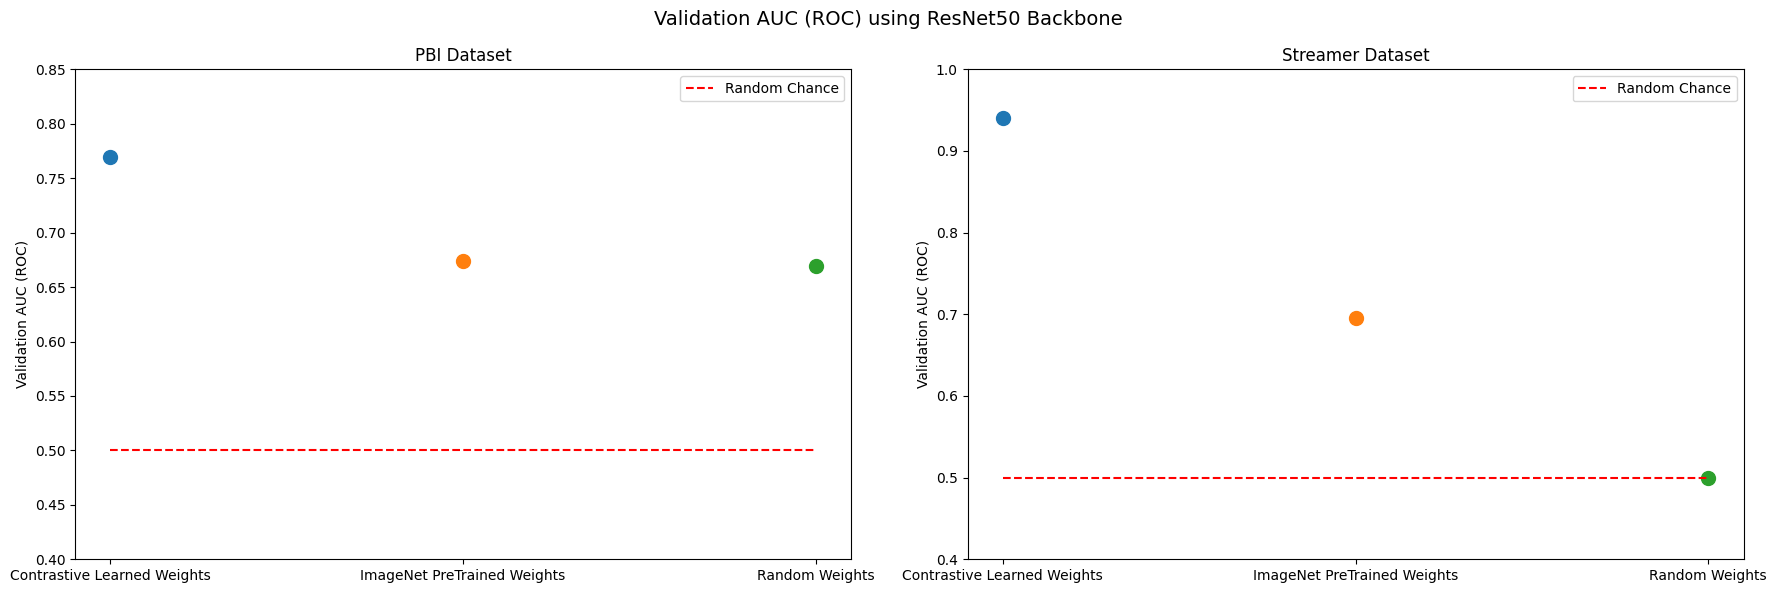

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# PBI Dataset
val_auc_pbi = {
    "Contrastive Learned Weights": contrastive_pbi_df.iloc[-1]["val_auc_roc"],
    "ImageNet PreTrained Weights": imagenet_pbi_df.iloc[-1]["val_auc_roc"],
    "Random Weights": random_pbi_df.iloc[-1]["val_auc_roc"],
    
}

for i, (key, value) in enumerate(val_auc_pbi.items()):
    ax1.scatter(i, value, s=100)
ax1.hlines(y=0.5, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax1.set_ylim(0.4, 0.85)
ax1.set_xticks(range(len(val_auc_pbi)))
ax1.set_xticklabels(list(val_auc_pbi.keys()))
ax1.set_ylabel("Validation AUC (ROC)")
ax1.legend()
ax1.set_title("PBI Dataset")

# Streamer Dataset
val_auc_streamer = {
    "Contrastive Learned Weights": contrastive_streamer_df.iloc[-1]["val_auc_roc"],
    "ImageNet PreTrained Weights": imagenet_streamer_df.iloc[-1]["val_auc_roc"],
    "Random Weights": random_streamer_df.iloc[-1]["val_auc_roc"],
}

for i, (key, value) in enumerate(val_auc_streamer.items()):
    ax2.scatter(i, value, s=100)
ax2.hlines(y=0.5, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax2.set_ylim(0.4, 1)
ax2.set_xticks(range(len(val_auc_streamer)))
ax2.set_xticklabels(list(val_auc_streamer.keys()))
ax2.set_ylabel("Validation AUC (ROC)")
ax2.legend()
ax2.set_title("Streamer Dataset")

fig.suptitle("Validation AUC (ROC) using ResNet50 Backbone", fontsize=14)
plt.tight_layout()
plt.savefig("figs/combined_validation_auc_roc.png")
plt.show()

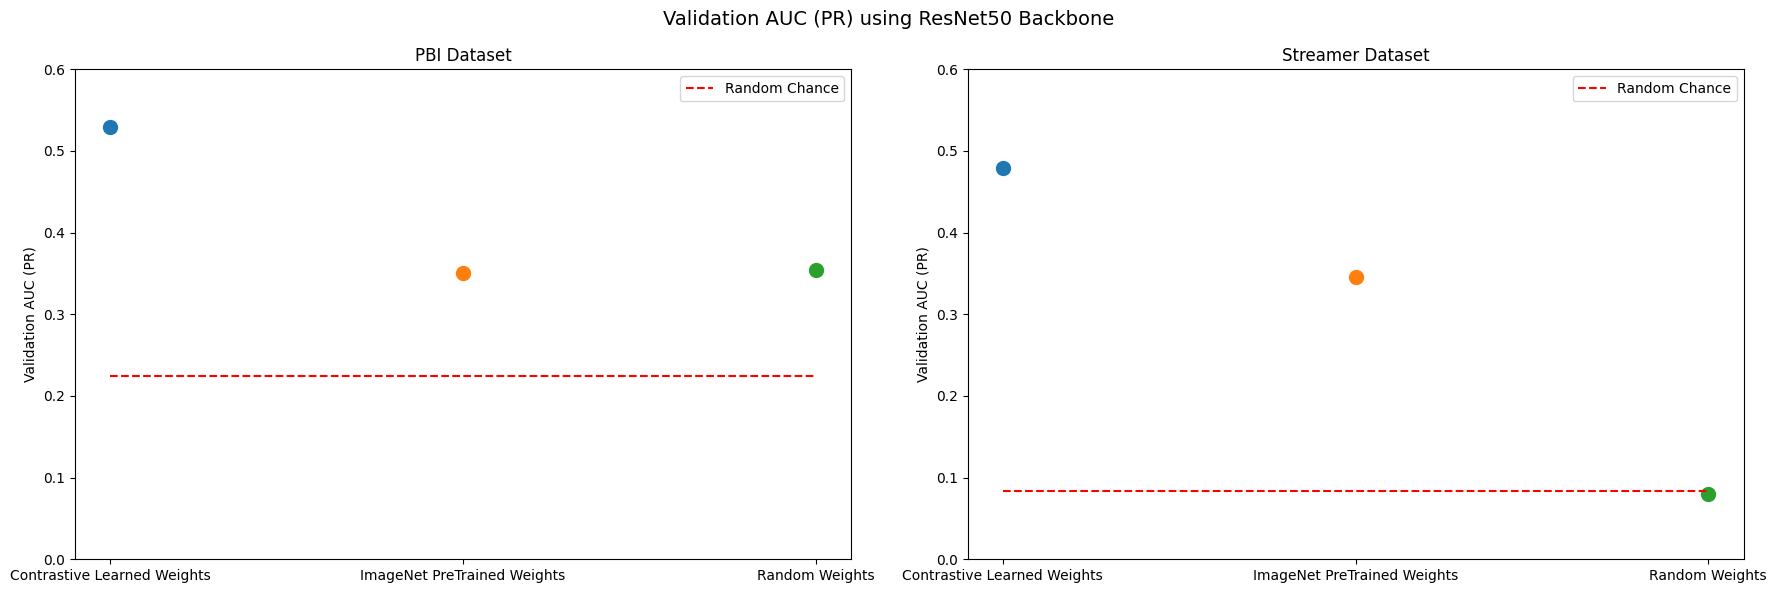

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# PBI Dataset
val_auc_pbi = {
    "Contrastive Learned Weights": contrastive_pbi_df.iloc[-1]["val_auc_pr"],
    "ImageNet PreTrained Weights": imagenet_pbi_df.iloc[-1]["val_auc_pr"],
    "Random Weights": random_pbi_df.iloc[-1]["val_auc_pr"],
}

for i, (key, value) in enumerate(val_auc_pbi.items()):
    ax1.scatter(i, value, s=100)
ax1.hlines(y=0.224, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax1.set_ylim(0, 0.6)
ax1.set_xticks(range(len(val_auc_pbi)))
ax1.set_xticklabels(list(val_auc_pbi.keys()))
ax1.set_ylabel("Validation AUC (PR)")
ax1.legend()
ax1.set_title("PBI Dataset")

# Streamer Dataset
val_auc_streamer = {
    "Contrastive Learned Weights": contrastive_streamer_df.iloc[-1]["val_auc_pr"],
    "ImageNet PreTrained Weights": imagenet_streamer_df.iloc[-1]["val_auc_pr"],
    "Random Weights": random_streamer_df.iloc[-1]["val_auc_pr"],
}

for i, (key, value) in enumerate(val_auc_streamer.items()):
    ax2.scatter(i, value, s=100)
ax2.hlines(y=0.084, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax2.set_ylim(0, 0.6)
ax2.set_xticks(range(len(val_auc_streamer)))
ax2.set_xticklabels(list(val_auc_streamer.keys()))
ax2.set_ylabel("Validation AUC (PR)")
ax2.legend()
ax2.set_title("Streamer Dataset")

fig.suptitle("Validation AUC (PR) using ResNet50 Backbone", fontsize=14)
plt.tight_layout()
plt.savefig("figs/combined_validation_auc_pr.png")
plt.show()

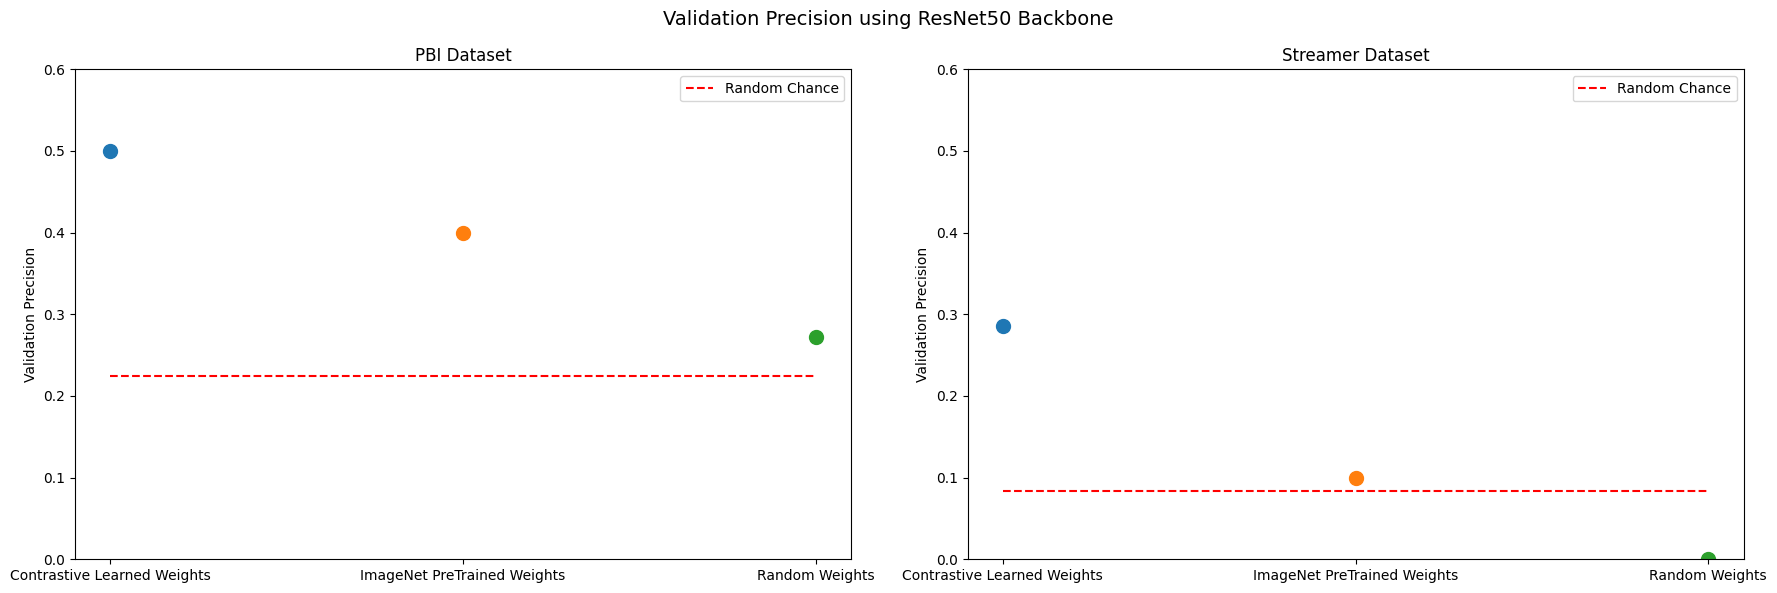

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# PBI Dataset
val_auc_pbi = {
    "Contrastive Learned Weights": contrastive_pbi_df.iloc[-1]["val_precision"],
    "ImageNet PreTrained Weights": imagenet_pbi_df.iloc[-1]["val_precision"],
    "Random Weights": random_pbi_df.iloc[-1]["val_precision"],
}

for i, (key, value) in enumerate(val_auc_pbi.items()):
    ax1.scatter(i, value, s=100)
ax1.hlines(y=0.224, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax1.set_ylim(0, 0.6)
ax1.set_xticks(range(len(val_auc_pbi)))
ax1.set_xticklabels(list(val_auc_pbi.keys()))
ax1.set_ylabel("Validation Precision")
ax1.legend()
ax1.set_title("PBI Dataset")

# Streamer Dataset
val_auc_streamer = {
    "Contrastive Learned Weights": contrastive_streamer_df.iloc[-1]["val_precision"],
    "ImageNet PreTrained Weights": imagenet_streamer_df.iloc[-1]["val_precision"],
    "Random Weights": random_streamer_df.iloc[-1]["val_precision"],
}

for i, (key, value) in enumerate(val_auc_streamer.items()):
    ax2.scatter(i, value, s=100)
ax2.hlines(y=0.084, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax2.set_ylim(0, 0.6)
ax2.set_xticks(range(len(val_auc_streamer)))
ax2.set_xticklabels(list(val_auc_streamer.keys()))
ax2.set_ylabel("Validation Precision")
ax2.legend()
ax2.set_title("Streamer Dataset")

fig.suptitle("Validation Precision using ResNet50 Backbone", fontsize=14)
plt.tight_layout()
plt.savefig("figs/combined_validation_precision.png")
plt.show()

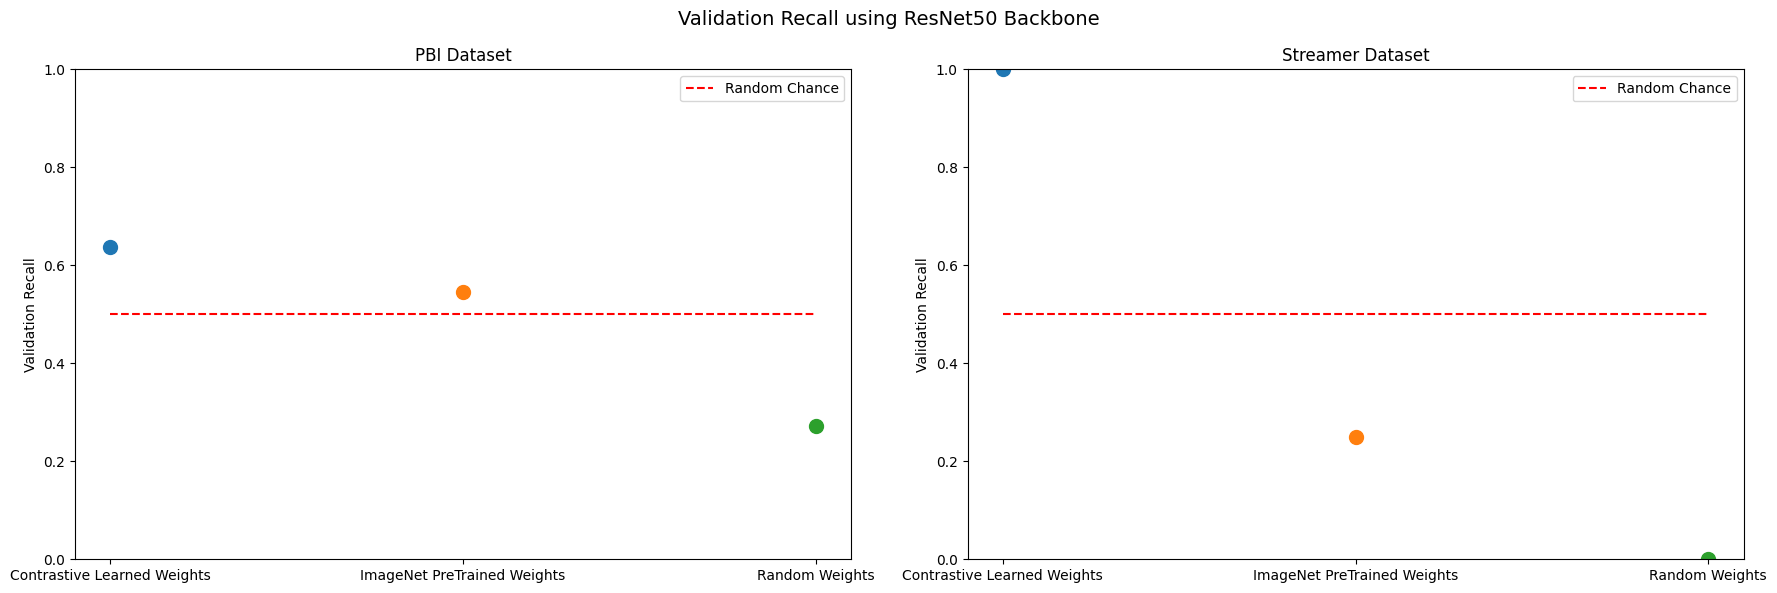

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# PBI Dataset
val_auc_pbi = {
    "Contrastive Learned Weights": contrastive_pbi_df.iloc[-1]["val_recall"],
    "ImageNet PreTrained Weights": imagenet_pbi_df.iloc[-1]["val_recall"],
    "Random Weights": random_pbi_df.iloc[-1]["val_recall"],
}

for i, (key, value) in enumerate(val_auc_pbi.items()):
    ax1.scatter(i, value, s=100)
ax1.hlines(y=0.5, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax1.set_ylim(0, 1)
ax1.set_xticks(range(len(val_auc_pbi)))
ax1.set_xticklabels(list(val_auc_pbi.keys()))
ax1.set_ylabel("Validation Recall")
ax1.legend()
ax1.set_title("PBI Dataset")

# Streamer Dataset
val_auc_streamer = {
    "Contrastive Learned Weights": contrastive_streamer_df.iloc[-1]["val_recall"],
    "ImageNet PreTrained Weights": imagenet_streamer_df.iloc[-1]["val_recall"],
    "Random Weights": random_streamer_df.iloc[-1]["val_recall"],
}

for i, (key, value) in enumerate(val_auc_streamer.items()):
    ax2.scatter(i, value, s=100)
ax2.hlines(y=0.5, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
ax2.set_ylim(0, 1)
ax2.set_xticks(range(len(val_auc_streamer)))
ax2.set_xticklabels(list(val_auc_streamer.keys()))
ax2.set_ylabel("Validation Recall")
ax2.legend()
ax2.set_title("Streamer Dataset")

fig.suptitle("Validation Recall using ResNet50 Backbone", fontsize=14)
plt.tight_layout()
plt.savefig("figs/combined_validation_recall.png")
plt.show()

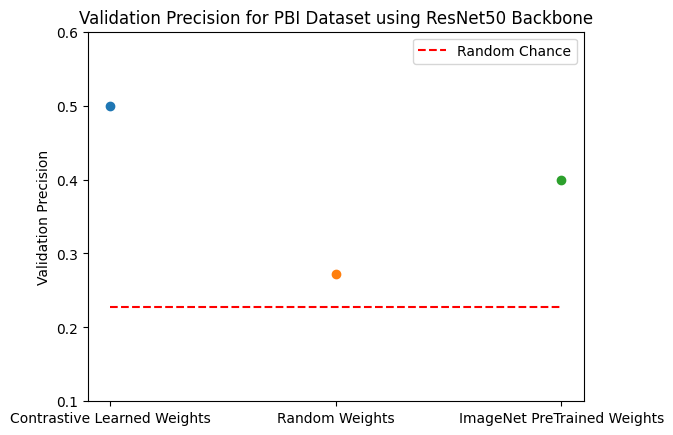

In [8]:
val_precision_pbi = {
    "Contrastive Learned Weights": contrastive_pbi_df.iloc[-1]["val_precision"],
    "Random Weights": random_pbi_df.iloc[-1]["val_precision"],
    "ImageNet PreTrained Weights": imagenet_pbi_df.iloc[-1]["val_precision"]
}

for i, (key, value) in enumerate(val_precision_pbi.items()):
    plt.scatter(i, value)
plt.hlines(y=0.228, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
plt.ylim(0.1, 0.6)
plt.xticks(range(len(val_precision_pbi)), list(val_precision_pbi.keys()))
plt.ylabel("Validation Precision")
plt.legend()
plt.title("Validation Precision for PBI Dataset using ResNet50 Backbone")
plt.savefig("figs/pbi_validation_precision.png")
plt.show()


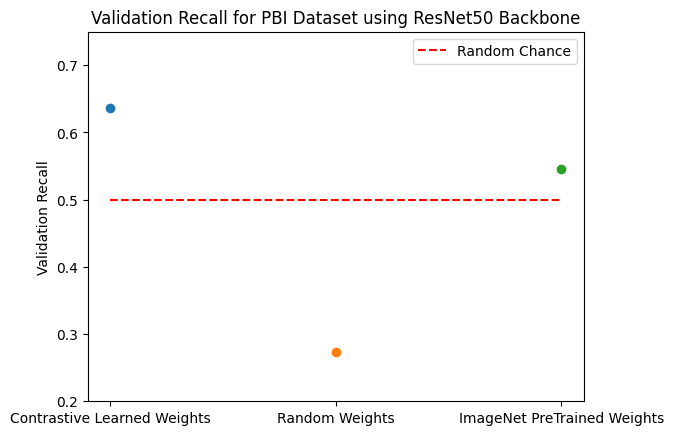

In [9]:
val_recall_pbi = {
    "Contrastive Learned Weights": contrastive_pbi_df.iloc[-1]["val_recall"],
    "Random Weights": random_pbi_df.iloc[-1]["val_recall"],
    "ImageNet PreTrained Weights": imagenet_pbi_df.iloc[-1]["val_recall"]
}

for i, (key, value) in enumerate(val_recall_pbi.items()):
    plt.scatter(i, value)
plt.hlines(y=0.5, xmin=0, xmax=2, colors="red", linestyles="dashed", label="Random Chance")
plt.ylim(0.2, 0.75)
plt.xticks(range(len(val_recall_pbi)), list(val_recall_pbi.keys()))
plt.ylabel("Validation Recall")
plt.legend()
plt.title("Validation Recall for PBI Dataset using ResNet50 Backbone")
plt.savefig("figs/pbi_validation_recall.png")
plt.show()
